In [102]:
"""
Test nuemrical optimaization of solutions where tace has been clipped by also clipping residual...
"""

'\nTest nuemrical optimaization of solutions where tace has been clipped by also clipping residual...\n'

In [103]:
import numpy as np
from scipy.sparse import lil_matrix, csr_matrix, csc_matrix, coo_matrix, bsr_matrix
from scipy.optimize import nnls, least_squares
from scipy.linalg import circulant

import matplotlib.pyplot as plt

from util.DataGen import nai_pulse
from util.Processing import td_convolve, td_nnlsr_deconvolve
from util.Plotting import plot_photons

In [104]:
n_trace = 1000
n_photons = 10
max_value = 40

seed = 0

[921  75 608 630 380   1 239 954  27 485]
(10,) (10,)
(10,) (1000,) (1000,)
535 460.02318918263654


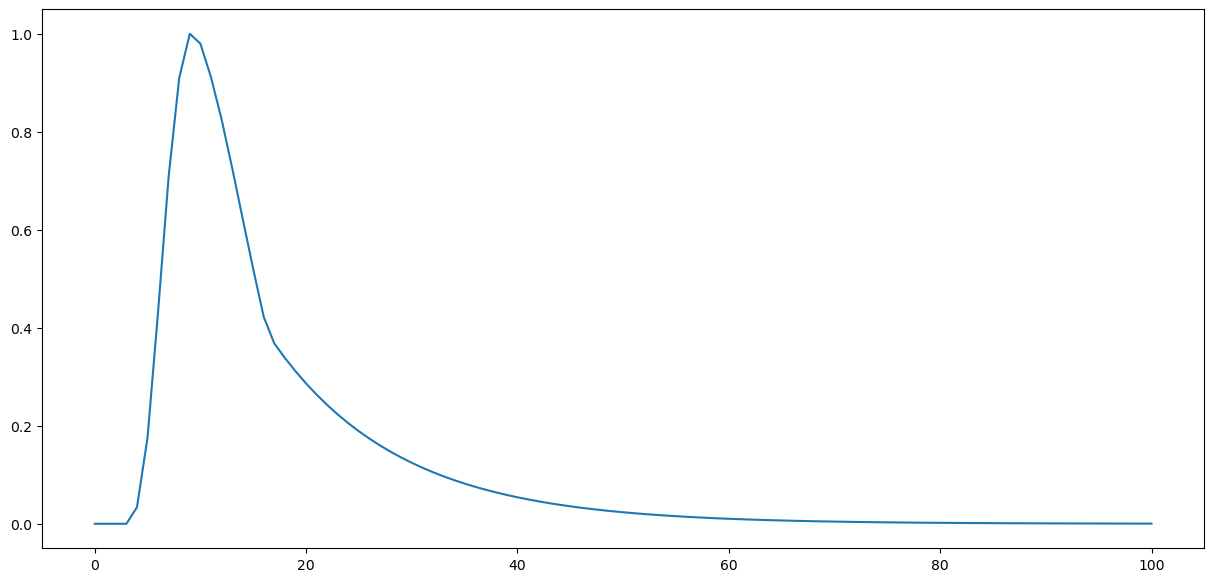

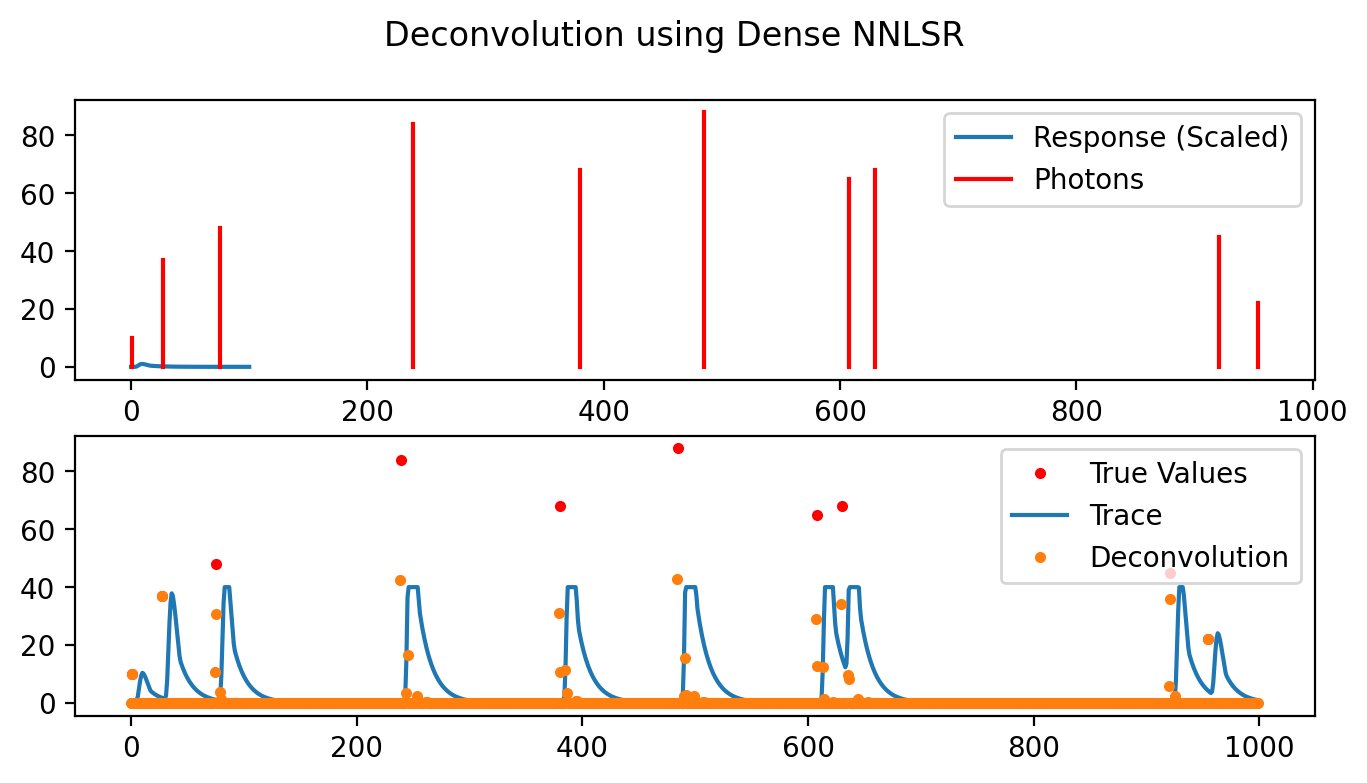

In [105]:
# Construct NNLSR manually using

np.random.seed(seed)
energy_list = np.random.randint(1, 100, n_photons)
indeces = np.random.choice(np.arange(n_trace), size=n_photons, replace=False)
print(indeces)
print(energy_list.shape, indeces.shape)
energy_trace = np.zeros(n_trace)
energy_trace[indeces] = energy_list

_, kernel = nai_pulse(1)

trace = td_convolve(x=energy_trace, kernel=kernel)
trace[trace > max_value] = max_value

deconvolved = td_nnlsr_deconvolve(y=trace, kernel=kernel)

print(energy_list.shape, energy_trace.shape, trace.shape)

plt.figure()
plt.plot(kernel)

fig, axes = plt.subplots(2, 1, figsize=(8, 4), dpi=200)
axes[0].plot(kernel, label='Response (Scaled)')
plot_photons(structure=axes[0], photons_=indeces, magnitude=energy_list, color='red',label_='Photons')

axes[1].plot(indeces, energy_trace[indeces], label='True Values', marker='.', linestyle='', color='r')
axes[1].plot(trace, label='Trace')
axes[1].plot(deconvolved, label='Deconvolution', marker='.', linestyle='')

fig.suptitle('Deconvolution using Dense NNLSR')
axes[0].legend()
axes[1].legend()

print(np.sum(energy_list), np.sum(deconvolved))

In [106]:
def nnlsr_residual(x, C, trace):
    # out = ((trace - x @ C) ** 2).sum()
    # out = ((trace - C @ x) ** 2).sum()
    # out = (trace - C @ x).sum()
    out = trace - C @ x
    return out

def soft_l1_loss(z):
    d1 = 2 * ((1 + z)**0.5 - 1)
    d2 = 2 * ((1 + z)**(-0.5))
    d3 = -2 * ((1 + z)**(-1.5))
    return np.stack((d1,d2,d3))

def l2_loss(z):
    d1 = np.sum(z**2, keepdims=True)
    d2 = np.sum(2 * z,  keepdims=True)
    d3 = np.sum(2 * np.ones_like(z), keepdims=True)
    return np.stack((d1,d2,d3))

def l1_loss(z):
    d1 = z
    d2 = np.ones_like(z)
    d3 = np.zeros_like(z)
    return np.stack((d1,d2,d3))

def l0_loss(z):
    d1 = z**(.5)
    d2 = .5 * z ** (-.5)
    d3 = -.25 * z ** (-1.5)
    return np.stack((d1,d2,d3))
    
def ln1_loss(z):
    d1 = z**(-.5)
    d2 = -.5 * z ** (-1.5)
    d3 = .75 * z ** (-2.5)
    return np.stack((d1,d2,d3))

In [107]:
def nnlsr_residual(x, C, trace, max_value_):
    estimate = C @ x
    
    # Bound estiamte such that values that have been clipped do not show
    # up as artifically large error.
    estimate[estimate > max_value_] = max_value_
    
    out = trace - estimate
    # print(type(out))
    return out

def nnlsr_sparse_weights_with_pad(kernel_, time_len):
    # returns sparse weight matrix of extended diagonal of weights.
    #         Weights should be used with a trace padded with zeros of
    #         at least length of kernel.
    #
    # param: kernel_ the unscaled kernel shape
    # param: time_len: The length of time to solve weights for.
    # returns: scipy.sparse.csr_matrix

    assert time_len > kernel_.size

    k = kernel_
    nk = kernel_.size
    t = time_len
    n_wiwth_pad = t + nk

    # Start with COO matrix (define with coordinates)
    data = np.tile(k, n_wiwth_pad).reshape(k.size, n_wiwth_pad)
    i = np.tile(np.arange(n_wiwth_pad), nk).reshape((nk, n_wiwth_pad)) + np.arange(nk)[:, None]
    j = np.tile(np.arange(n_wiwth_pad), nk).reshape(nk, n_wiwth_pad)
    matrix = coo_matrix((data.ravel(), (j.T.ravel(),i.T.ravel())), (n_wiwth_pad + nk + 1, n_wiwth_pad + nk + 1))
    matrix = lil_matrix(matrix) # make subscriptable to slice to desired size and values

    # bsr matrix efficient for math operations, reccomended by scipy for new general work
    final_matrix = bsr_matrix(matrix[:n_wiwth_pad, :n_wiwth_pad])

    del matrix, data, i ,j
    return final_matrix

In [108]:
C = nnlsr_sparse_weights_with_pad(kernel, trace.size).T
n_trace = C.shape[0]
x0 = np.ones(n_trace)

padded_trace = np.ones(n_trace)
padded_trace[:trace.size] = trace

print(x0.shape, C.shape, energy_trace.shape)

def my_learn_loss(z):
    # d1 = np.sum(z**2, keepdims=True)
    # d2 = np.sum(2 * z,  keepdims=True)
    # d3 = np.sum(2 * np.ones_like(z), keepdims=True)
    # return np.stack((d1,d2,d3))
    assert False
    

solution = least_squares(fun=nnlsr_residual,
                         jac='cs',
                         method='trf', # use with bounds!
                         bounds=[0, np.inf],
                         args=(C, padded_trace, max_value),
                         x0=x0,
                         x_scale=10,
                         diff_step=.1,
                         # loss=soft_l1_loss,
                         # loss=l2_loss,
                         # loss=l1_loss,
                         # loss=l0_loss,
                         loss='linear', # beset with noise...
                         # loss='soft_l1', # best for noiseless...
                         jac_sparsity=C,   # not necessary, but speeds things up a lot which will be useful for scaling to high n
                         ftol=1E-15,
                         max_nfev=100,
                         verbose=2
                         )

(1101,) (1101, 1101) (1000,)
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         9.0191e+04                                    2.50e+02    
       1              2         5.1865e+04      3.83e+04       2.63e+01       4.65e+02    
       2              3         1.9790e+04      3.21e+04       2.02e+01       2.02e+02    
       3              4         5.0986e+03      1.47e+04       2.06e+01       5.41e+01    
       4              5         1.3795e+03      3.72e+03       2.13e+01       1.43e+01    
       5              6         6.1217e+02      7.67e+02       4.36e+00       5.76e+01    
       6              7         5.7129e+02      4.09e+01       1.23e+00       2.48e+01    
       7              8         4.1330e+02      1.58e+02       1.75e+01       1.51e+02    
       8              9         3.4787e+02      6.54e+01       1.54e+01       1.84e+02    
       9             10         2.7149e+02      7.64e+01     

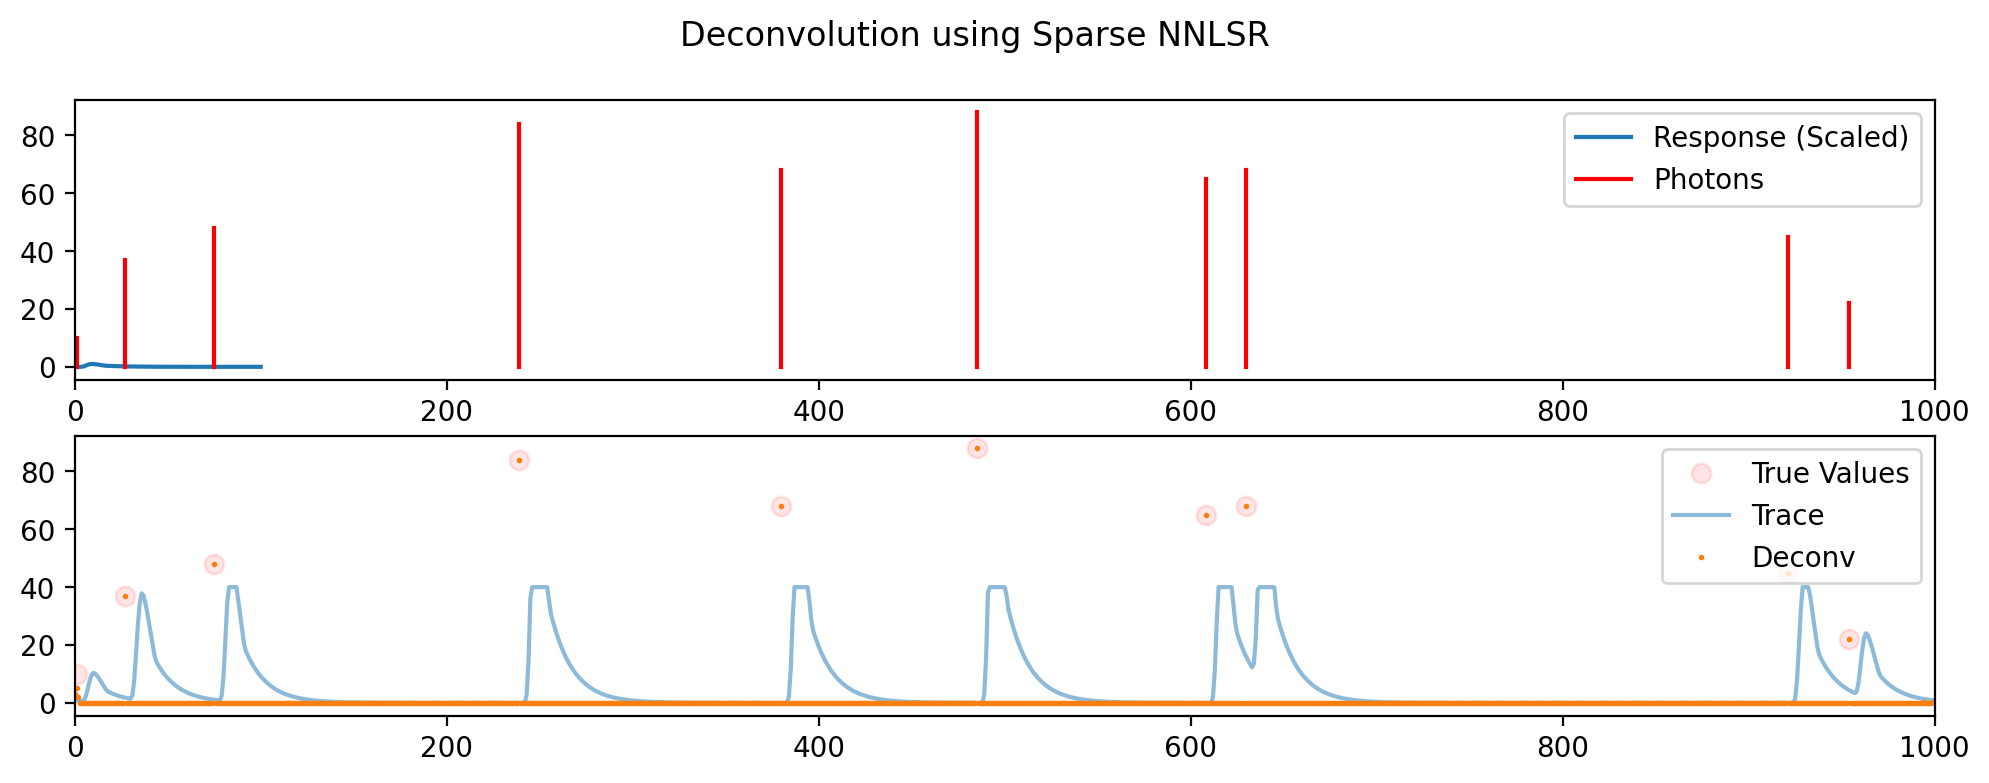

In [109]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4), dpi=200)
axes[0].plot(kernel, label='Response (Scaled)')
plot_photons(structure=axes[0], photons_=indeces, magnitude=energy_list, color='red',label_='Photons')

axes[1].plot(indeces, energy_trace[indeces], label='True Values', marker='o', markersize=7, linestyle='', color='r', alpha=.1)
axes[1].plot(trace, label='Trace', alpha=.5)
axes[1].plot(solution.x, '.', label='Deconv', markersize=2)
axes[0].set_xlim(0, trace.size)
axes[1].set_xlim(0, trace.size)

fig.suptitle('Deconvolution using Sparse NNLSR')
axes[0].legend()
axes[1].legend(loc='upper right')    